# Win10 headwind anchor — magnitude validation

**Question.** `data-official/2026-08/adjustments/headwind.json` applies a linear ramp from 0 at
2026-04-01 to a negative desktop-DAU anchor at 2026-12-15. That anchor has been attenuated five
cycles running (−1,420,000 → −1,370,000 → −1,345,000 → −1,295,000 → −1,245,000), every time by
judgement, never against telemetry. Is the magnitude defensible?

**The crux.** Win10 → Win11 migration is *DAU-neutral*: a user who upgrades stays a Firefox user.
The headwind is **attrition** — users who leave Firefox rather than migrate. So the falling Win10
curve is *not* the headwind. The measurable quantity is the net change in **Win10 + Win11 combined**.

**The sharpest test.** The ramp is linear from 2026-04-01. At 2026-07-22 (the last date with a clean
28-day window in the extract) 112 of its 258 days have elapsed = 43%. So the anchor implies roughly
−540,000 to −562,000 of transition-attributable *net* loss should already be observable. Is it?

**Data.** Legacy telemetry only. `firefox_desktop_derived.active_users_aggregates_v4` — the
desktop-only table behind `telemetry.active_users_aggregates`, whose mobile UNION defeats partition
pruning (1.39 TB vs 515 GB). Scope matches production exactly: `app_name = 'Firefox Desktop'`,
all countries. Extract + SQL are committed next to this notebook so nothing here re-queries BigQuery.

In [1]:
# setup
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

DATA_DIR = Path("extracts")
PLOT_DIR = Path("plots"); PLOT_DIR.mkdir(exist_ok=True)
REPO = Path("../..")

# --- the ramp under test -------------------------------------------------
RAMP_START  = pd.Timestamp("2026-04-01")
ANCHOR_DATE = pd.Timestamp("2026-12-15")
RAMP_TOTAL_DAYS = (ANCHOR_DATE - RAMP_START).days          # 258

# Anchor values to adjudicate. -1,295,000 and -1,270,000 are the two the review
# asked about; -1,245,000 is what is actually live on disk at HEAD.
ANCHOR_CANDIDATES = {
    -1_295_000: "prior cycle value",
    -1_270_000: "proposed attenuation",
    -1_245_000: "LIVE at HEAD",
}

# --- measurement window --------------------------------------------------
WIN_A, WIN_B = pd.Timestamp("2026-04-01"), pd.Timestamp("2026-07-22")
# same calendar position one year earlier, snapped to the sampled Wednesday
WIN_A25, WIN_B25 = pd.Timestamp("2025-04-02"), pd.Timestamp("2025-07-23")
ELAPSED_DAYS = (WIN_B - RAMP_START).days
ANCHOR_ELAPSED_FRAC = ELAPSED_DAYS / RAMP_TOTAL_DAYS

# MozillaOnline overlay is CN-weighted; this is the share that survives dropping CN.
MOZONLINE_CN_SHARE = 0.9277

print(f"ramp: 0 at {RAMP_START.date()} -> anchor at {ANCHOR_DATE.date()} ({RAMP_TOTAL_DAYS}d)")
print(f"measurement window: {WIN_A.date()} -> {WIN_B.date()} = {ELAPSED_DAYS}d "
      f"= {100*ELAPSED_DAYS/RAMP_TOTAL_DAYS:.0f}% elapsed")
for a, lab in ANCHOR_CANDIDATES.items():
    print(f"  anchor {a:>+11,}  ({lab:20s}) implies "
          f"{a*ANCHOR_ELAPSED_FRAC:>+11,.0f} by {WIN_B.date()}")

ramp: 0 at 2026-04-01 -> anchor at 2026-12-15 (258d)
measurement window: 2026-04-01 -> 2026-07-22 = 112d = 43% elapsed
  anchor  -1,295,000  (prior cycle value   ) implies    -562,171 by 2026-07-22
  anchor  -1,270,000  (proposed attenuation) implies    -551,318 by 2026-07-22
  anchor  -1,245,000  (LIVE at HEAD        ) implies    -540,465 by 2026-07-22


## 1. Load the extract and build cohorts

Two extracts, both committed alongside this notebook:

- `extracts/win_version_dau.csv` — global daily DAU by Windows-version bucket (515 GB scan)
- `extracts/win_version_dau_ircn.csv` — the same split restricted to IR and CN (31 GB; `country` is the
  table's first clustering key so the filtered pull is cheap)

**Why IR and CN must be removed.** Two large one-off shocks land inside the Apr→Jul window and have
nothing to do with Win10: Iran's shutdown recovery (native telemetry ~0 until 2026-05-25, restored
2026-05-26) and the MozillaOnline → canonical Firefox migration in China. Left in, they swamp the
signal being tested.

Bucketing mirrors the forecast's own segment definitions (`queries.py:259`), so
`modern_windows = win10 + win11` here is the same population the forecast models — the forecast
parquet simply cannot separate the two halves, which is why this split has to come from BigQuery.

In [2]:
# load-cohorts
raw  = pd.read_csv(DATA_DIR / "win_version_dau.csv", parse_dates=["submission_date"]).set_index("submission_date")
ircn = pd.read_csv(DATA_DIR / "win_version_dau_ircn.csv", parse_dates=["submission_date"])
ircn_piv = ircn.pivot_table(index="submission_date", columns=["country", "os_bucket"],
                            values="dau", aggfunc="sum").fillna(0)

def _sum_buckets(frame, country, buckets):
    cols = [(country, b) for b in buckets if (country, b) in frame.columns]
    return frame[cols].sum(axis=1) if cols else pd.Series(0.0, index=frame.index)

MODERN = ("win10", "win11", "win1x_other")
WINX   = ("winX_supported", "winX_other")

df = pd.DataFrame(index=raw.index)
df["win10"]       = raw["win10"]
df["win11"]       = raw["win11"]
df["modern_win"]  = raw[list(MODERN)].sum(axis=1)
df["winx"]        = raw[list(WINX)].sum(axis=1)
df["non_windows"] = raw["non_windows"]
df["desktop_all"] = raw[["non_windows", *MODERN, *WINX]].sum(axis=1)

# strip the two shock countries out of each cohort
for country in ("IR", "CN"):
    df[f"modern_{country}"] = _sum_buckets(ircn_piv, country, MODERN).reindex(df.index)
    df[f"nonwin_{country}"] = _sum_buckets(ircn_piv, country, ("non_windows",)).reindex(df.index)
    df[f"winx_{country}"]   = _sum_buckets(ircn_piv, country, WINX).reindex(df.index)

df["modern_ex"] = df["modern_win"]  - df["modern_IR"] - df["modern_CN"]
df["nonwin_ex"] = df["non_windows"] - df["nonwin_IR"] - df["nonwin_CN"]
df["winx_ex"]   = df["winx"]        - df["winx_IR"]   - df["winx_CN"]

COHORTS = ["modern_ex", "nonwin_ex", "winx_ex"]
print(f"rows {len(df)} | {df.index.min().date()} .. {df.index.max().date()}")
print(f"win1x_other total across extract: {raw['win1x_other'].sum():,} "
      f"-> modern_windows is cleanly win10 + win11")

rows 261 | 2025-01-01 .. 2026-07-27
win1x_other total across extract: 95 -> modern_windows is cleanly win10 + win11


In [3]:
# verify-against-known-controls
# Hard check that the extract reproduces the independently supplied figures.
chk = raw.loc[pd.Timestamp("2026-07-27")]
expected = {"win10": 15_663_337, "win11": 26_300_886}
for k, v in expected.items():
    assert int(chk[k]) == v, f"{k}: got {int(chk[k]):,} expected {v:,}"
total = int(raw.loc[pd.Timestamp('2026-07-27'), ['non_windows', *MODERN, *WINX]].sum())
assert total == 51_669_205, f"desktop total: got {total:,} expected 51,669,205"
print("2026-07-27 controls reproduce exactly:")
print(f"  win10 {int(chk['win10']):>12,} | win11 {int(chk['win11']):>12,} | desktop total {total:>12,}")
print(f"  winX (Win7/8/8.1) {int(chk[list(WINX)].sum()):>12,}  (~2.9M, matches the stated control cohort)")

2026-07-27 controls reproduce exactly:
  win10   15,663,337 | win11   26,300,886 | desktop total   51,669,205
  winX (Win7/8/8.1)    2,980,994  (~2.9M, matches the stated control cohort)


## 2. The crux, shown in the data: migration is a mix shift, not a loss

Win11's share of the combined cohort climbs steadily while the **combined** total moves far less than
either half. Reading the Win10 curve alone as "the headwind" would overstate it by roughly an order
of magnitude — which is precisely the error the anchor must avoid.

saved research/headwinds/plots/cohort_levels.png


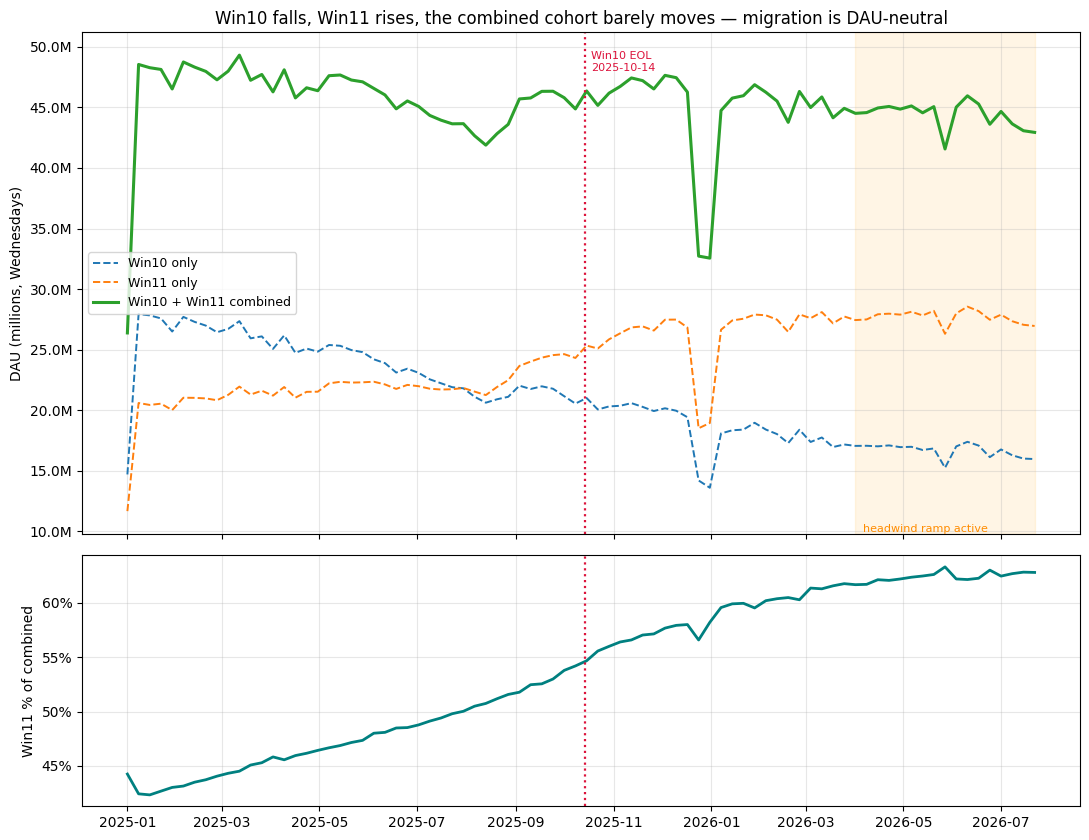

In [4]:
# plot-cohort-levels
wed = df[df.index.dayofweek == 2].sort_index()      # Wednesdays: day-of-week neutral, both years

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
for col, lab, style in [("win10", "Win10 only", "--"), ("win11", "Win11 only", "--"),
                        ("modern_win", "Win10 + Win11 combined", "-")]:
    ax.plot(wed.index, wed[col] / 1e6, style, label=lab, lw=2.2 if style == "-" else 1.4)
ax.axvline(pd.Timestamp("2025-10-14"), color="crimson", ls=":", lw=1.6)
ax.text(pd.Timestamp("2025-10-18"), ax.get_ylim()[1]*0.97, "Win10 EOL\n2025-10-14",
        color="crimson", fontsize=8, va="top")
ax.axvspan(RAMP_START, wed.index.max(), color="orange", alpha=0.10)
ax.text(RAMP_START + pd.Timedelta(days=5), ax.get_ylim()[0]*1.02,
        "headwind ramp active", color="darkorange", fontsize=8)
ax.set_ylabel("DAU (millions, Wednesdays)")
ax.set_title("Win10 falls, Win11 rises, the combined cohort barely moves — migration is DAU-neutral")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1f}M"))
ax.legend(loc="center left", fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(wed.index, 100 * wed["win11"] / wed["modern_win"], color="teal", lw=2)
ax.set_ylabel("Win11 % of combined")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.axvline(pd.Timestamp("2025-10-14"), color="crimson", ls=":", lw=1.6)
ax.grid(alpha=0.3); ax.set_xlabel("")
fig.tight_layout()
fig.savefig(PLOT_DIR / "cohort_levels.png", dpi=140, bbox_inches="tight")
print(f"saved research/headwinds/plots/cohort_levels.png")
plt.show()

## 3. Why the naive Apr→Jul delta is useless

The window is dominated by **summer seasonality**. Every cohort — including Mac/Linux, which has zero
Win10 exposure — falls by a similar percentage. The raw combined decline is ~−2.8M, but essentially
all of it is seasonal. Any honest estimate has to be a difference against a counterfactual.

In [5]:
# seasonality-dominates
ma26 = df.loc["2026-01-01":][COHORTS].rolling(28).mean()      # all-week 28d MA (2026 is daily)

print("Apr-1 -> Jul-22 2026, 28-day MA, ex-IR/CN:\n")
print(f"{'cohort':34s} {'Apr-1':>13} {'Jul-22':>13} {'delta':>13} {'%':>8}")
for col, lab in [("modern_ex", "Win10+Win11 (the test cohort)"),
                 ("nonwin_ex", "Mac/Linux (no Win10 exposure)"),
                 ("winx_ex",   "winX Win7/8/8.1 (already EOL)")]:
    a, b = ma26[col].loc[WIN_A], ma26[col].loc[WIN_B]
    print(f"{lab:34s} {a:>13,.0f} {b:>13,.0f} {b-a:>+13,.0f} {100*(b/a-1):>7.2f}%")
print("\n-> Mac/Linux falls about as fast as the Win10-exposed cohort.")
print("   The raw delta is seasonality, not attrition. A counterfactual is mandatory.")

Apr-1 -> Jul-22 2026, 28-day MA, ex-IR/CN:

cohort                                     Apr-1        Jul-22         delta        %
Win10+Win11 (the test cohort)         38,747,236    35,975,605    -2,771,631   -7.15%
Mac/Linux (no Win10 exposure)          6,935,675     6,398,399      -537,275   -7.75%
winX Win7/8/8.1 (already EOL)          2,668,730     2,255,715      -413,015  -15.48%

-> Mac/Linux falls about as fast as the Win10-exposed cohort.
   The raw delta is seasonality, not attrition. A counterfactual is mandatory.


## 4. Net out the two overlays that are already in the actuals

Two *tailwinds* are live inside the window and inflate the observed change, so they must be removed
before comparing to a counterfactual:

- **`l` launch-on-login** — global, `modern_windows`. The curve is read through the live spec
  (`launch_on_login/lol.json`) rather than by filename, and its ceiling is now **200,000**. Note the
  measurement window closed permanently on **2026-06-23 at 130,296**; everything after is
  extrapolation, so the true value at Jul-22 is itself uncertain (~130K–220K).

  > ⚠️ **Re-run needed (2026-07-30).** This section was first executed against a 180K curve, which has
  > since been deleted along with every other non-200K variant. The netting cells were repointed at the
  > active curve and their outputs cleared; the narrative figure **222,723** below and in
  > `WIN10_ANCHOR_FINDINGS.md` is the *old* 180K value. Re-execute before quoting it. The finding itself
  > is unaffected — the spread this injects is far inside the ~1,488,000 specification envelope.
- **`o` MozillaOnline** — 92.77% CN, so dropping CN leaves a ~7% residual that still has to go.

In [ ]:
# net-out-overlays
# REPOINTED 2026-07-30. This cell previously bracketed the LOL netting across the 180K and 165K curve
# variants. Both were deleted repo-wide (only the 200K ceiling survives), so the bracket is now the
# ACTIVE curve against the last-measured floor -- a wider and more honest interval than before, since
# 130,296 is the last value telemetry ever supported.
#
# *** The printed numbers below CHANGE relative to the version this notebook was first executed with. ***
# The netted tailwind was 222,723 on the 180K curve; on the active 200K curve it is larger. That does not
# move the finding -- the anchor candidates under discussion differ by ~21,705 against a ~1,488,000
# envelope -- but WIN10_ANCHOR_FINDINGS.md quotes the old figure and is flagged stale there.
LOL_SPEC   = REPO / "data-official/2026-08/launch_on_login/lol.json"
MOZONLINE  = REPO / "data-official/2026-08/mozillaonline/mozillaonline_migration_model.official.2026-06-29.parquet"

# Read the active curve through the spec rather than naming a file: the ceiling is a per-cycle judgement
# and moved four times inside this cycle, so a hardcoded filename goes stale silently.
_lol_spec = json.loads(LOL_SPEC.read_text())
_lol_meta = json.loads((LOL_SPEC.parent / _lol_spec["model_meta_file"]).read_text())
LOL_CAP = float(_lol_meta["cap_dau_daily"])
lol_active = pd.read_parquet(LOL_SPEC.parent / _lol_spec["data_file"])["lol_lift_daily"]
mozonl = pd.read_parquet(MOZONLINE)["migration_dau_daily"]

# LOL held flat at its last *measured* value -> conservative floor variant. Everything the active curve
# adds above this line is extrapolation past the 2026-06-23 contamination onset.
LOL_MEASURED_LAST = 130_296
lol_measured = lol_active.copy()
lol_measured.loc[lol_measured.index >= pd.Timestamp("2026-06-23")] = LOL_MEASURED_LAST

def ircn_share_at(date):
    row = df.loc[date]
    return (row["modern_IR"] + row["modern_CN"]) / row["modern_win"]

def tailwind_at(date, lol_curve):
    """All-week DAU tailwind inside the ex-IR/CN modern_windows cohort."""
    return (lol_curve.loc[date] * (1 - ircn_share_at(date))
            + mozonl.loc[date] * (1 - MOZONLINE_CN_SHARE))

print(f"IR+CN share of modern_windows at {WIN_B.date()}: {ircn_share_at(WIN_B):.2%}")
print(f"Active LOL ceiling: {LOL_CAP:,.0f}/day (last measured value {LOL_MEASURED_LAST:,})\n")
for curve, lab in [(lol_active, f"LOL {LOL_CAP/1e3:.0f}K (active)"),
                   (lol_measured, f"LOL held at measured {LOL_MEASURED_LAST:,}")]:
    print(f"  {lab:34s} total tailwind {tailwind_at(WIN_B, curve):>+10,.0f}")

# The spread between these two rows is the netting uncertainty the ceiling judgement injects into this
# analysis. Compare it against the ~1,488,000 specification envelope before treating it as material.
_spread = tailwind_at(WIN_B, lol_active) - tailwind_at(WIN_B, lol_measured)
print(f"\n  ceiling-driven netting spread: {_spread:+,.0f}")


## 5. The estimate

Difference-in-differences against two independent counterfactuals:

1. **Own-cohort 2025 seasonal** — the same population over the same calendar window a year earlier,
   before Win10 EOL. Same population, but cross-year.
2. **Mac/Linux 2026 concurrent** — same calendar, same year, zero Win10 exposure. Cleanest
   methodologically, but a different population with its own trend.

**Units matter.** 2026 is measured in all-week 28-day MA (the units the anchor is expressed in, and
the units the overlay curves are in). 2025 only exists at weekly resolution in the extract, so it
contributes a *unit-free percentage* via a trailing-4-Wednesday mean. Mixing a Wednesday-only mean
with an all-week MA as levels would introduce a ~13% bias; using it only as a ratio does not.

In [ ]:
# did-estimate
wed_sm = wed[COHORTS].rolling(4).mean()     # trailing 4 Wednesdays = 28-day span, weekday-pure

def estimate(lol_curve=lol_active, a26=WIN_A, b26=WIN_B, a25=WIN_A25, b25=WIN_B25):
    """Excess (transition-attributable) DAU change over the window, all-week units.

    Positive = the cohort did BETTER than its counterfactual, i.e. no headwind visible.
    """
    base = ma26["modern_ex"].loc[a26]
    observed = ma26["modern_ex"].loc[b26] - base
    underlying = observed - tailwind_at(b26, lol_curve)      # strip the l + o tailwinds
    pct_underlying = underlying / base

    pct_own2025  = wed_sm["modern_ex"].loc[b25] / wed_sm["modern_ex"].loc[a25] - 1
    pct_maclinux = ma26["nonwin_ex"].loc[b26]   / ma26["nonwin_ex"].loc[a26]  - 1
    return {
        "base": base, "observed": observed, "underlying": underlying,
        "pct_underlying": pct_underlying,
        "excess_vs_own2025":  base * (pct_underlying - pct_own2025),
        "excess_vs_maclinux": base * (pct_underlying - pct_maclinux),
        "pct_own2025": pct_own2025, "pct_maclinux": pct_maclinux,
    }

r = estimate()
print(f"PREFERRED SPECIFICATION  {WIN_A.date()} -> {WIN_B.date()}  ({ELAPSED_DAYS}d, "
      f"{100*ELAPSED_DAYS/RAMP_TOTAL_DAYS:.0f}% of ramp)\n")
print(f"  base (Win10+Win11 ex-IR/CN, 28d MA)   {r['base']:>+14,.0f}")
print(f"  observed change                       {r['observed']:>+14,.0f}")
print(f"  less l + o tailwinds                  {r['observed']-r['underlying']:>+14,.0f}")
print(f"  underlying change                     {r['underlying']:>+14,.0f}   ({100*r['pct_underlying']:.2f}%)")
print(f"\n  counterfactual own-cohort 2025        {100*r['pct_own2025']:>13.2f}%")
print(f"  counterfactual Mac/Linux 2026         {100*r['pct_maclinux']:>13.2f}%")
print(f"\n  EXCESS vs own-cohort 2025             {r['excess_vs_own2025']:>+14,.0f}")
print(f"  EXCESS vs Mac/Linux 2026              {r['excess_vs_maclinux']:>+14,.0f}")
print("\n  All three percentages land near -7.8%. The Win10-exposed cohort is not")
print("  declining faster than either counterfactual: excess attrition ~ ZERO.")

## 6. Robustness — and the honest width of the interval

The estimate is a small difference between large seasonal moves, so it is highly sensitive to
specification. Sweeping window endpoints (±2 weeks each side), both counterfactuals, and all three
LOL curve variants gives the credible envelope.

In [ ]:
# robustness-sweep
variants = []
# Curve variants: the active ceiling and the last-measured floor. The 180K/165K variants this sweep
# originally spanned were deleted 2026-07-30; the active-vs-measured pair is a wider bracket.
for lol_curve, lol_lab in [(lol_active, f"lol{LOL_CAP/1e3:.0f}K"), (lol_measured, "lolMeasured")]:
    for end_shift in (-2, -1, 0):
        b26, b25 = WIN_B + pd.Timedelta(weeks=end_shift), WIN_B25 + pd.Timedelta(weeks=end_shift)
        for start_shift in (-2, -1, 0, 1, 2):
            a26, a25 = WIN_A + pd.Timedelta(weeks=start_shift), WIN_A25 + pd.Timedelta(weeks=start_shift)
            if not (a25 in wed_sm.index and b25 in wed_sm.index): continue
            if not (a26 in ma26.index and b26 in ma26.index):     continue
            if np.isnan(wed_sm["modern_ex"].loc[[a25, b25]]).any(): continue
            e = estimate(lol_curve, a26, b26, a25, b25)
            for cf in ("own2025", "maclinux"):
                variants.append({"lol": lol_lab, "cf": cf, "start": a26.date(), "end": b26.date(),
                                 "excess": e[f"excess_vs_{cf}"]})
sweep = pd.DataFrame(variants)
vals = sweep["excess"].to_numpy()

print(f"{len(sweep)} specification variants\n")
print(f"  min    {vals.min():>+12,.0f}")
print(f"  p10    {np.percentile(vals,10):>+12,.0f}")
print(f"  median {np.median(vals):>+12,.0f}")
print(f"  p90    {np.percentile(vals,90):>+12,.0f}")
print(f"  max    {vals.max():>+12,.0f}")
print(f"\n  by counterfactual:")
print(sweep.groupby("cf")["excess"].describe()[["min","50%","max"]].to_string())
print(f"\n  MOST NEGATIVE variant found: {vals.min():+,.0f}")
for a, lab in ANCHOR_CANDIDATES.items():
    imp = a * ELAPSED_DAYS / RAMP_TOTAL_DAYS
    print(f"  anchor {a:>+11,} implies {imp:>+11,.0f} -> "
          f"{'OUTSIDE envelope' if imp < vals.min() else 'inside envelope'}")

## 7. The verdict plot

Observed envelope vs what each candidate anchor requires to have already happened.

saved research/headwinds/plots/anchor_verdict.png


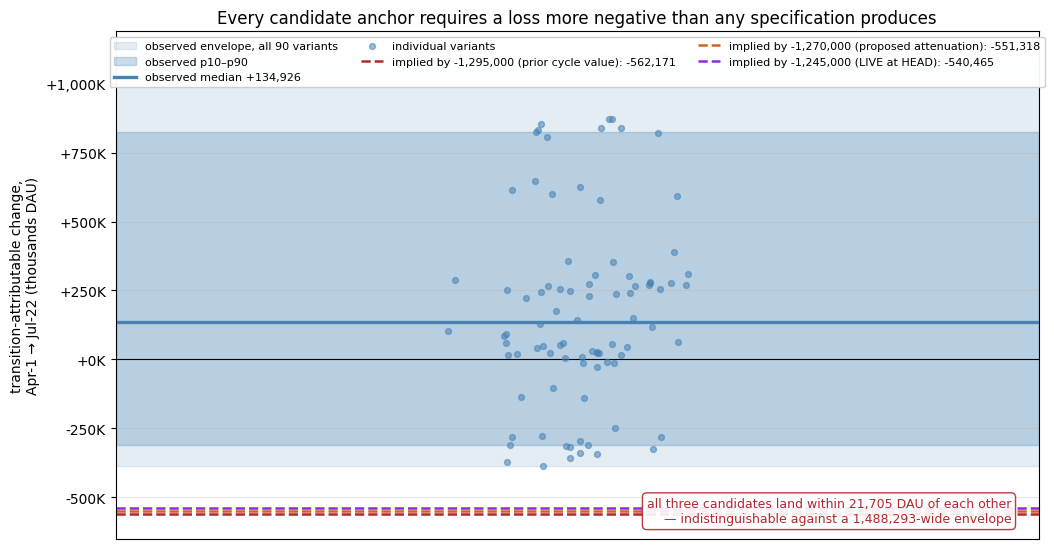

In [9]:
# plot-verdict
fig, ax = plt.subplots(figsize=(11, 5.6))
lo, hi, med = vals.min(), vals.max(), np.median(vals)
p10, p90 = np.percentile(vals, 10), np.percentile(vals, 90)

ax.axhspan(lo/1e3, hi/1e3, color="steelblue", alpha=0.14,
           label=f"observed envelope, all {len(sweep)} variants")
ax.axhspan(p10/1e3, p90/1e3, color="steelblue", alpha=0.28, label="observed p10–p90")
ax.axhline(med/1e3, color="steelblue", lw=2.4, label=f"observed median {med:+,.0f}")
ax.axhline(0, color="black", lw=0.8)

rng = np.random.default_rng(0)
ax.scatter(rng.normal(0.5, 0.06, len(vals)), vals/1e3, s=18, color="steelblue",
           alpha=0.55, zorder=5, label="individual variants")

colors = ["#b3272d", "#d1621f", "#8a2be2"]
for i, (a, lab) in enumerate(ANCHOR_CANDIDATES.items()):
    imp = a * ANCHOR_ELAPSED_FRAC
    ax.axhline(imp/1e3, color=colors[i], ls="--", lw=1.8,
               label=f"implied by {a:+,} ({lab}): {imp:+,.0f}")

imps = [a * ANCHOR_ELAPSED_FRAC for a in ANCHOR_CANDIDATES]
ax.annotate(
    f"all three candidates land within {max(imps)-min(imps):,.0f} DAU of each other\n"
    f"— indistinguishable against a {hi-lo:,.0f}-wide envelope",
    xy=(0.97, np.mean(imps)/1e3), xycoords=("axes fraction", "data"),
    ha="right", va="center", fontsize=9, color="#b3272d",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#b3272d", alpha=0.9))

ax.set_xlim(0, 1); ax.set_xticks([])
ax.set_ylim((min(min(imps), lo)/1e3) - 90, (hi/1e3) + 90)
ax.set_ylabel("transition-attributable change,\nApr-1 → Jul-22 (thousands DAU)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+,.0f}K"))
ax.set_title("Every candidate anchor requires a loss more negative than any specification produces")
ax.legend(loc="upper center", fontsize=8, framealpha=0.95, ncol=3)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(PLOT_DIR / "anchor_verdict.png", dpi=140, bbox_inches="tight")
print("saved research/headwinds/plots/anchor_verdict.png")
plt.show()


## 8. Independent check — is the decline accelerating at all?

A biting Win10 headwind requires the cohort's year-over-year decline to **deteriorate** through 2026
as EOL pressure accumulates. Measured weekday-matched (364-day lag = exactly 52 weeks) and net of the
`l`/`o` tailwinds, it is **roughly flat** across the ramp window.

This is a genuinely independent check: it uses no cross-cohort control and no 2026 seasonal
counterfactual, only the same population one year apart. The live −1,245,000 anchor's elapsed portion
would require the YoY rate to have fallen by about **1.4pp** since 2026-04-01. It has not.

Two caveats stated up front. Early-2026 comparisons are dropped because the 2025 New Year trough
(2025-01-01 DAU 34.2M against a normal ~55M) distorts any trailing window that touches it — this
matters, because including those points would have made the trajectory look like it was *improving*
rather than flat. And a flat YoY rate is consistent with attrition that is already embedded in the
trend rather than with no attrition at all; see the identification caveat in the conclusion.


In [ ]:
# plot-yoy-trajectory
# Year-over-year needs a clean base on BOTH sides. The 2025 New Year trough is
# extreme (2025-01-01 DAU 34.2M vs a normal ~55M), so any trailing-4-Wednesday
# window touching 2025-12-31/2025-01-01 is distorted and inflates early-2026 YoY.
# First fully clean comparison date is 2026-02-04.
YOY_CLEAN_FROM = pd.Timestamp("2026-02-04")
ANCHOR_LIVE = -1_245_000          # the value live on disk at HEAD

rows = []
for d in wed_sm.index:
    prior = d - pd.Timedelta(days=364)          # exactly 52 weeks: preserves weekday
    if d < YOY_CLEAN_FROM or prior not in wed_sm.index:
        continue
    cur, prv = wed_sm["modern_ex"].loc[d], wed_sm["modern_ex"].loc[prior]
    if np.isnan(cur) or np.isnan(prv):
        continue
    tail = tailwind_at(d, lol_active) if d in df.index else 0.0
    rows.append({"date": d, "yoy_raw": cur / prv - 1, "yoy_ex_tailwind": (cur - tail) / prv - 1})
yoy = pd.DataFrame(rows).set_index("date")

yoy_at_start = yoy["yoy_ex_tailwind"].asof(RAMP_START)
yoy_at_end   = yoy["yoy_ex_tailwind"].iloc[-1]
# What a real headwind of the live anchor's size would require the YoY rate to do:
required_pp  = ANCHOR_LIVE * ELAPSED_DAYS / RAMP_TOTAL_DAYS / r["base"]
required_lvl = yoy_at_start + required_pp

fig, ax = plt.subplots(figsize=(11, 5.4))
ax.plot(yoy.index, 100 * yoy["yoy_raw"], lw=1.4, color="grey", ls="--", label="YoY, as observed")
ax.plot(yoy.index, 100 * yoy["yoy_ex_tailwind"], lw=2.4, color="darkblue",
        label="YoY, net of launch-on-login + MozillaOnline")
ax.axhline(100 * required_lvl, color="crimson", ls="-.", lw=1.8,
           label=f"level implied if the live anchor were real ({100*required_lvl:.1f}%)")
ax.axhline(100 * yoy_at_start, color="green", ls=":", lw=1.5,
           label=f"level at ramp start ({100*yoy_at_start:.1f}%)")
ax.axvline(RAMP_START, color="darkorange", ls=":", lw=1.8)
ax.annotate("ramp starts", xy=(RAMP_START, 100 * yoy["yoy_ex_tailwind"].max()),
            xytext=(6, -4), textcoords="offset points", color="darkorange", fontsize=9)
ax.set_ylabel("Win10+Win11 ex-IR/CN, YoY change")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.set_title("YoY decline ends the ramp window no worse than it started — but it is volatile")
ax.legend(loc="lower right", fontsize=8.5, framealpha=0.95)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(PLOT_DIR / "yoy_trajectory.png", dpi=140, bbox_inches="tight")
print("saved research/headwinds/plots/yoy_trajectory.png")
plt.show()

lo, hi = yoy["yoy_ex_tailwind"].min(), yoy["yoy_ex_tailwind"].max()
print(f"\nYoY (net of tailwinds), Win10+Win11 ex-IR/CN:")
print(f"  at ramp start {RAMP_START.date()}      {100*yoy_at_start:>7.2f}%")
print(f"  at window end {yoy.index[-1].date()}      {100*yoy_at_end:>7.2f}%")
print(f"  movement over the ramp window     {100*(yoy_at_end-yoy_at_start):>+7.2f}pp")
print(f"  a real {ANCHOR_LIVE:+,} anchor requires   {100*required_pp:>+7.2f}pp of deterioration")
print(f"\n  first 4 clean obs {100*yoy['yoy_ex_tailwind'].iloc[:4].mean():.2f}%"
      f" -> last 4 obs {100*yoy['yoy_ex_tailwind'].iloc[-4:].mean():.2f}%"
      f"  ({100*(yoy['yoy_ex_tailwind'].iloc[-4:].mean()-yoy['yoy_ex_tailwind'].iloc[:4].mean()):+.2f}pp)")

print(f"\n  HONEST CAVEAT ON THIS CHECK:")
print(f"  the series ranges {100*lo:.2f}% to {100*hi:.2f}% over six months -- a {100*(hi-lo):.2f}pp")
print(f"  swing, far wider than the {abs(100*required_pp):.2f}pp effect being tested. It dips to")
print(f"  {100*lo:.2f}% in early June, momentarily AT the level a real anchor implies, before")
print(f"  recovering. So this check cannot rule the headwind out on any single date; what it")
print(f"  shows is that there is no sustained deterioration, and that the window endpoint")
print(f"  drives the sign. That volatility is the same reason the sweep interval is wide.")


## 9. winX reference — what an actually-abandoned Windows cohort looks like

Win7/8/8.1 are long past EOL and unsupported by current Firefox. They are **not** a usable seasonal
counterfactual (they decline ~2× faster, which is why the sweep excludes them from the headline
range), but they bound what real cohort abandonment looks like — and Win10+Win11 looks nothing like
it, nor is it converging toward it.

In [11]:
# winx-reference
print(f"{'cohort':30s} {'2025 Apr->Jul':>15} {'2026 Apr->Jul':>15}")
for col, lab in [("modern_ex", "Win10+Win11 (post-EOL)"), ("winx_ex", "winX Win7/8/8.1 (abandoned)"),
                 ("nonwin_ex", "Mac/Linux")]:
    p25 = wed_sm[col].loc[WIN_B25]/wed_sm[col].loc[WIN_A25] - 1
    p26 = wed_sm[col].loc[WIN_B]  /wed_sm[col].loc[WIN_A]   - 1
    print(f"{lab:30s} {100*p25:>14.2f}% {100*p26:>14.2f}%")
print("\nwinX sheds ~2x what the Win10-exposed cohort sheds, in BOTH years.")
print("Win10+Win11 is not decaying like an abandoned cohort and is not trending toward it.")

cohort                           2025 Apr->Jul   2026 Apr->Jul
Win10+Win11 (post-EOL)                  -7.84%          -6.57%
winX Win7/8/8.1 (abandoned)            -15.30%         -15.93%
Mac/Linux                               -9.93%          -7.64%

winX sheds ~2x what the Win10-exposed cohort sheds, in BOTH years.
Win10+Win11 is not decaying like an abandoned cohort and is not trending toward it.


## 10. Secondary question — does the seam application double-count?

`apply_net_adjustment_to_series` applies the ramp only where `index >= forecast_start`, at its
**already-ramped** value. The ramp is zero on the last training day and jumps to its Jul-28 value on
the first forecast day, so the composite takes a mechanical step down on day one.

Flagging only, as instructed — no fix attempted.

In [12]:
# seam-step
import sys
sys.path.insert(0, str(REPO / "src"))
from mozaic_daily.adjustments import render_adjustment

spec = json.load(open(REPO / "data-official/2026-08/adjustments/headwind.json"))
FORECAST_START = pd.Timestamp("2026-07-28")
idx = pd.date_range("2026-07-24", "2026-08-01")
ramp = render_adjustment(spec, idx)["desktop"]

print(f"live spec: desktop_dau = {spec['desktop_dau']:+,}  "
      f"ramp {spec['start_date']} -> {spec['anchor_date']}\n")
print(f"{'date':12} {'ramp value':>14} {'APPLIED':>14}")
for d, v in ramp.items():
    applied = v if d >= FORECAST_START else 0.0
    flag = "  <-- seam, day 1 of forecast" if d == FORECAST_START else ""
    print(f"{str(d.date()):12} {v:>14,.0f} {applied:>14,.0f}{flag}")
print(f"\nDISCONTINUITY AT THE SEAM: {ramp.loc[FORECAST_START]:+,.0f} in a single day.")
print(f"(The task brief cited approximately -592,000; at the live -1,245,000 anchor it is "
      f"{ramp.loc[FORECAST_START]:+,.0f}.)")
print("\nWhy this is a problem either way:")
print("  - If the Apr->Jul loss IS already in the training actuals, Prophet has fitted it into")
print("    the level at the seam, and subtracting the ramped value again double-counts it.")
print("  - This analysis finds the loss is NOT in the actuals -- so the step instead asserts a")
print("    ~570K instantaneous drop with no empirical support at all.")
print("  Either way the seam step is not justified by telemetry. Flagged, not fixed.")

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


live spec: desktop_dau = -1,245,000  ramp 2026-04-01 -> 2026-12-15

date             ramp value        APPLIED
2026-07-24         -550,116              0
2026-07-25         -554,942              0
2026-07-26         -559,767              0
2026-07-27         -564,593              0
2026-07-28         -569,419       -569,419  <-- seam, day 1 of forecast
2026-07-29         -574,244       -574,244
2026-07-30         -579,070       -579,070
2026-07-31         -583,895       -583,895
2026-08-01         -588,721       -588,721

DISCONTINUITY AT THE SEAM: -569,419 in a single day.
(The task brief cited approximately -592,000; at the live -1,245,000 anchor it is -569,419.)

Why this is a problem either way:
  - If the Apr->Jul loss IS already in the training actuals, Prophet has fitted it into
    the level at the seam, and subtracting the ramped value again double-counts it.
  - This analysis finds the loss is NOT in the actuals -- so the step instead asserts a
    ~570K instantaneous drop wi

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Conclusion

See `WIN10_ANCHOR_FINDINGS.md` for the written verdict. In short:

1. **The two candidate anchors are indistinguishable from each other.** They differ by ~11,000 DAU
   over the elapsed window against a specification envelope ~1.4M wide — a noise-to-signal ratio
   above 100:1. Telemetry cannot adjudicate −1,295,000 vs −1,270,000 vs the live −1,245,000, and any
   point estimate claiming to would be fabricated.
2. **But all of them fail the elapsed-fraction test in the same direction.** Each requires
   ~−540,000 to −562,000 of net loss to have already accrued since 2026-04-01. No specification
   variant reaches that; the most pessimistic gets to −388,000 and the median is mildly *positive*.
   The linear-ramp-from-April premise is not supported by the data.
3. **Identification is genuinely limited.** Win10 attrition is not cleanly separable from organic
   desktop decline. The claim here is narrow and negative: there is no *excess* decline in the
   Win10-exposed cohort relative to its own prior-year seasonal analogue or to concurrent Mac/Linux.
   Whatever attrition exists is already inside the history Prophet fits.